In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
import src.utils as utils
from src.visualization import Visualization
import copy
from src.risk_computations import RiskComputations, diff_to_exponents


In [2]:
T=1000
sigma = 0.1
dim = 50

eta = 0.1
eta_range = np.logspace(-4, 0, 50)
t_values = np.linspace(0, T-1, 10, dtype=int)

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.2)
constant = ConstantSchedule(steps=T, base_lr=eta)
linear = WSDSchedule(steps=T, base_lr=eta, cooldown_len=1.)

x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))


schedules1 = [wsd, constant, linear]
schedules2 = copy.deepcopy(schedules1)

risks_computations_sgd = RiskComputations(model, x0, schedules=schedules1, schedules_names=["wsd", "constant", "linear"], sgd_class=SGD)
risks_computations_noisy_gd = RiskComputations(model, x0, schedules=schedules2, schedules_names=["wsd", "constant", "linear"], sgd_class=NoisyGD)

Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_17-17-15.json
Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_17-17-17.json
Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_17-17-21.json
Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_17-17-24.json
Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_17-17-27.json
Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_17-17-29.json
Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_17-17-32.json
Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_17-17-34.json
Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_va

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_17-18-15.json
Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_17-18-18.json


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_17-18-22.json
Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_17-18-24.json


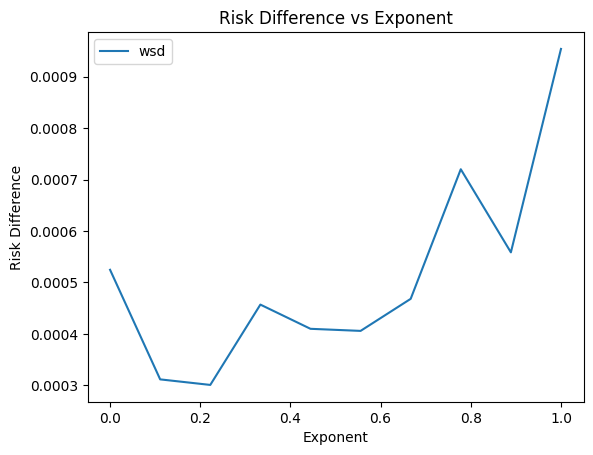

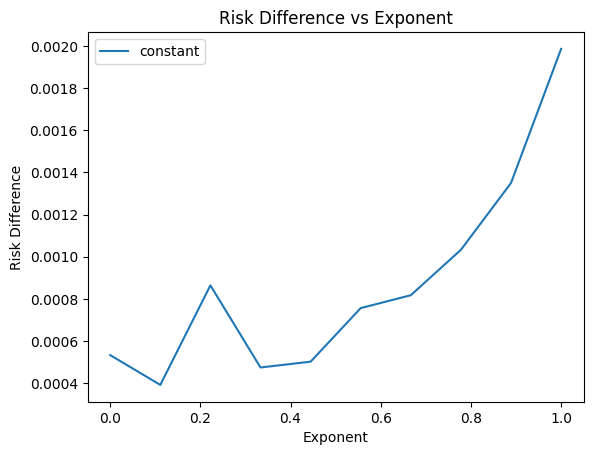

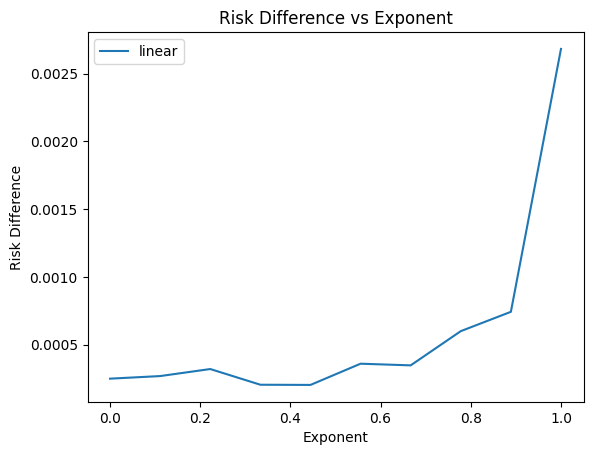

In [ ]:


diff_results = diff_to_exponents(np.linspace(0, 1, 10)) 


for name in ["wsd", "constant", "linear"]:
    plt.plot(list(diff_results.keys()), [diff_results[exponent][name] for exponent in diff_results], label=name)
    plt.xlabel("Exponent")
    plt.ylabel("Risk Difference")
    plt.title("Risk Difference vs Exponent")
    plt.legend()
plt.show()